In [1]:
!rm -rf PyTorch-VAE
!git clone https://github.com/longwei-xiao/PyTorch-VAE.git
%cd PyTorch-VAE

Cloning into 'PyTorch-VAE'...
remote: Enumerating objects: 992, done.
remote: Counting objects: 100% (471/471), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 992 (delta 423), reused 422 (delta 407), pack-reused 521 (from 3)
Receiving objects: 100% (992/992), 159.32 MiB | 15.79 MiB/s, done.
Resolving deltas: 100% (664/664), done.
Updating files: 100% (166/166), done.
/content/PyTorch-VAE


In [2]:
!pip install scikit-learn xgboost matplotlib pandas numpy torch tqdm

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Point 1: pred=30.154, gt=30.988, error=-0.833
Point 2: pred=27.790, gt=23.983, error=3.808
Point 3: pred=28.322, gt=27.350, error=0.972
Point 4: pred=26.987, gt=26.728, error=0.259
Point 5: pred=27.357, gt=27.060, error=0.297
Point 6: pred=24.154, gt=24.649, error=-0.495
Point 7: pred=28.348, gt=26.990, error=1.357
Point 8: pred=29.329, gt=28.105, error=1.225
Point 9: pred=28.369, gt=28.955, error=-0.586
Point 10: pred=27.750, gt=30.011, error=-2.261
Saved GPR results in folder: gpr/


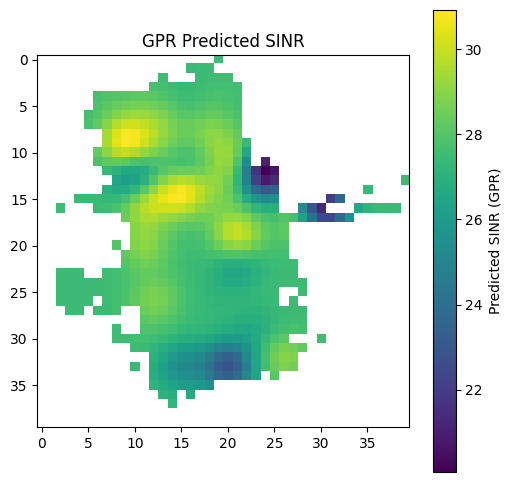

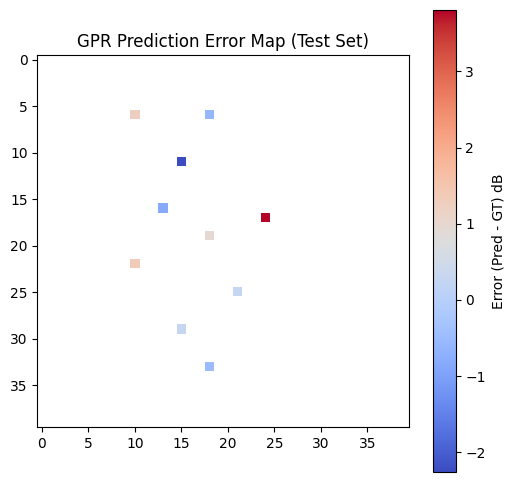

In [3]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

# -------------------------
# Parameters
# -------------------------
H, W = 40, 40

# -------------------------
# Load data
# -------------------------
df_coords = pd.read_csv("original_1600_grid_points.csv")
df_valid = pd.read_csv("inside.csv", header=None, names=['X','Y'])
df_measurements = pd.read_csv("combined_sinr.csv")  # 30 × 7700
test_sinr = pd.read_csv("combined_test_sinr.csv")
img = plt.imread("map_of_R1_Hall.png")
img_h, img_w = img.shape[0], img.shape[1]

# -------------------------
# Coordinate mapping
# -------------------------
def coords_to_grid_binning(df, H, W, img_h, img_w):
    xs = df["X"].values.astype(float)
    ys = df["Y"].values.astype(float)
    x_idx = np.clip((xs / img_w * W).astype(int), 0, W-1)
    y_idx = np.clip((ys / img_h * H).astype(int), 0, H-1)
    return y_idx, x_idx

valid_y, valid_x = coords_to_grid_binning(df_valid, H, W, img_h, img_w)
valid_mask = torch.zeros((H, W), dtype=torch.bool)
for y, x in zip(valid_y, valid_x):
    valid_mask[y, x] = 1

# Fill holes
def fill_holes_8_neighbors(mask):
    H, W = mask.shape
    new_mask = mask.copy()
    for y in range(1, H-1):
        for x in range(1, W-1):
            if mask[y,x] == 0 and np.sum(mask[y-1:y+2, x-1:x+2]) == 8:
                new_mask[y,x] = 1
    return new_mask

valid_indices = fill_holes_8_neighbors(valid_mask.cpu().numpy())

# -------------------------
# Prepare training data
# -------------------------
sinr_y, sinr_x = coords_to_grid_binning(df_measurements[['X','Y']], H, W, img_h, img_w)
X_train = np.vstack([sinr_x, sinr_y]).T  # shape (30,2)

# Average measurements **per point**, not per sensor
data_array = df_measurements.iloc[:, 2:].values.astype(np.float32)
Y_train = data_array.mean(axis=1)  # shape (30,)

# Normalize coordinates for GPR
X_train_norm = X_train / np.array([[W-1, H-1]])

# Prediction grid
grid_xy = np.array([(x, y) for y in range(H) for x in range(W)])
grid_xy_norm = grid_xy / np.array([[W-1, H-1]])

# -------------------------
# Train GPR (optimized for sparse points)
# -------------------------
kernel = ConstantKernel(1.0, (0.1, 10.0)) * RBF(length_scale=0.2, length_scale_bounds=(0.05, 1.0)) \
         + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 0.1))

gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True, n_restarts_optimizer=5)
gpr.fit(X_train_norm, Y_train)

# Predict
sinr_pred_gpr, sinr_std = gpr.predict(grid_xy_norm, return_std=True)
sinr_map_gpr = sinr_pred_gpr.reshape(H, W)
sinr_std_map = sinr_std.reshape(H, W)

# -------------------------
# Mask inside region
# -------------------------
inside_map_gpr = np.full((H, W), np.nan, dtype=np.float32)
ys_valid, xs_valid = np.where(valid_indices == True)
for y, x in zip(ys_valid, xs_valid):
    inside_map_gpr[y, x] = sinr_map_gpr[y, x]

# -------------------------
# Plot GPR prediction
# -------------------------
import os
os.makedirs("gpr", exist_ok=True)
plt.figure(figsize=(6,6))
plt.imshow(inside_map_gpr, cmap='viridis', origin='upper')
plt.colorbar(label="Predicted SINR (GPR)")
plt.title("GPR Predicted SINR")
plt.savefig("gpr/GPR_SINR.png", dpi=300, bbox_inches='tight')

# -------------------------
# Test errors
# -------------------------
sinr_yt, sinr_xt = coords_to_grid_binning(test_sinr[['X','Y']], H, W, img_h, img_w)
X_test = np.vstack([sinr_xt, sinr_yt]).T
X_test_norm = X_test / np.array([[W-1, H-1]])
test_array = test_sinr.iloc[:, 2:].values.astype(np.float32)
Y_test = test_array.mean(axis=1)

sinr_pred_test = gpr.predict(X_test_norm)
errors_gpr = sinr_pred_test - Y_test

for i, (pred, gt, err) in enumerate(zip(sinr_pred_test, Y_test, errors_gpr)):
    print(f"Point {i+1}: pred={pred:.3f}, gt={gt:.3f}, error={err:.3f}")

# -------------------------
# Test error map
# -------------------------
error_map_gpr = np.full((H, W), np.nan, dtype=np.float32)
for i, (x, y) in enumerate(X_test):
    error_map_gpr[y, x] = errors_gpr[i]

plt.figure(figsize=(6,6))
plt.imshow(error_map_gpr, cmap="coolwarm", origin='upper')
plt.colorbar(label="Error (Pred - GT) dB")
plt.title("GPR Prediction Error Map (Test Set)")
plt.savefig("gpr/test_error.png", dpi=300, bbox_inches='tight')

print("Saved GPR results in folder: gpr/")


c:\Users\suram\anaconda3\envs\pytor_env\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Point 1: pred=30.983, gt=30.988, error=-0.004
Point 2: pred=23.986, gt=23.983, error=0.004
Point 3: pred=27.351, gt=27.350, error=0.001
Point 4: pred=26.728, gt=26.728, error=0.000
Point 5: pred=27.058, gt=27.060, error=-0.002
Point 6: pred=24.653, gt=24.649, error=0.004
Point 7: pred=26.992, gt=26.990, error=0.002
Point 8: pred=28.105, gt=28.105, error=-0.000
Point 9: pred=28.954, gt=28.955, error=-0.001
Point 10: pred=30.011, gt=30.011, error=-0.000
Saved GPR results in folder: gpr/


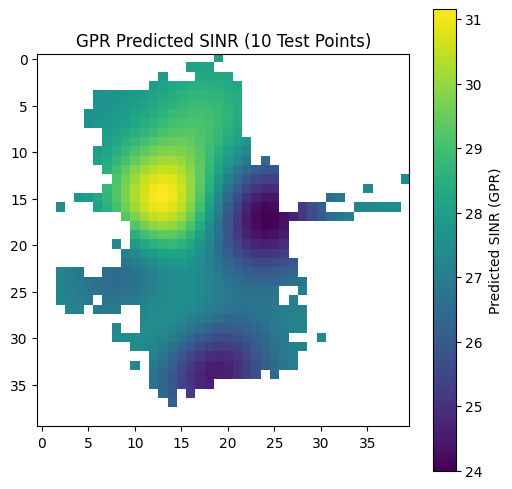

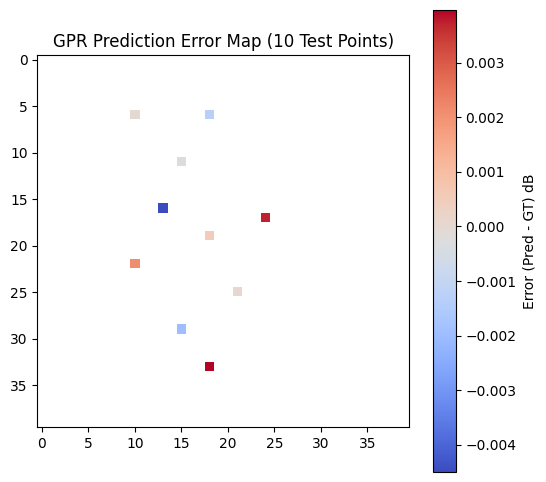

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

# -------------------------
# Parameters
# -------------------------
H, W = 40, 40

# -------------------------
# Load data
# -------------------------
df_valid = pd.read_csv("inside.csv", header=None, names=['X','Y'])
test_sinr = pd.read_csv("combined_test_sinr.csv")
img = plt.imread("map_of_R1_Hall.png")
img_h, img_w = img.shape[0], img.shape[1]

# -------------------------
# Coordinate mapping
# -------------------------
def coords_to_grid_binning(df, H, W, img_h, img_w):
    xs = df["X"].values.astype(float)
    ys = df["Y"].values.astype(float)
    x_idx = np.clip((xs / img_w * W).astype(int), 0, W-1)
    y_idx = np.clip((ys / img_h * H).astype(int), 0, H-1)
    return y_idx, x_idx

valid_y, valid_x = coords_to_grid_binning(df_valid, H, W, img_h, img_w)
valid_mask = torch.zeros((H, W), dtype=torch.bool)

for y, x in zip(valid_y, valid_x):
    valid_mask[y, x] = 1

# Fill holes
def fill_holes_8_neighbors(mask):
    H, W = mask.shape
    new_mask = mask.copy()
    for y in range(1, H-1):
        for x in range(1, W-1):
            if mask[y,x] == 0 and np.sum(mask[y-1:y+2, x-1:x+2]) == 8:
                new_mask[y,x] = 1
    return new_mask

valid_indices = fill_holes_8_neighbors(valid_mask.cpu().numpy())

# -------------------------
# Prepare training data from 10 test points
# -------------------------
sinr_yt, sinr_xt = coords_to_grid_binning(test_sinr[['X','Y']], H, W, img_h, img_w)
X_train = np.vstack([sinr_xt, sinr_yt]).T
test_array = test_sinr.iloc[:, 2:].values.astype(np.float32)
Y_train = test_array.mean(axis=1)

# Normalize coordinates for GPR
X_train_norm = X_train / np.array([[W-1, H-1]])

# Prediction grid
grid_xy = np.array([(x, y) for y in range(H) for x in range(W)])
grid_xy_norm = grid_xy / np.array([[W-1, H-1]])

# -------------------------
# Train GPR
# -------------------------
# Added backslash '\' below for line continuation so syntax is valid
kernel = ConstantKernel(1.0, (0.1, 10.0)) * RBF(length_scale=0.2, length_scale_bounds=(0.05, 1.0)) \
         + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 0.1))

gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True, n_restarts_optimizer=5)
gpr.fit(X_train_norm, Y_train)

# Predict
sinr_pred_gpr, sinr_std = gpr.predict(grid_xy_norm, return_std=True)
sinr_map_gpr = sinr_pred_gpr.reshape(H, W)
sinr_std_map = sinr_std.reshape(H, W)

# -------------------------
# Mask inside region
# -------------------------
inside_map_gpr = np.full((H, W), np.nan, dtype=np.float32)
ys_valid, xs_valid = np.where(valid_indices == True)

for y, x in zip(ys_valid, xs_valid):
    inside_map_gpr[y, x] = sinr_map_gpr[y, x]

# -------------------------
# Plot GPR prediction
# -------------------------
import os
os.makedirs("gpr", exist_ok=True)
plt.figure(figsize=(6,6))
plt.imshow(inside_map_gpr, cmap='viridis', origin='upper')
plt.colorbar(label="Predicted SINR (GPR)")
plt.title("GPR Predicted SINR (10 Test Points)")
#plt.savefig("gpr/GPR_SINR_10points.png", dpi=300, bbox_inches='tight')

# -------------------------
# Test errors (leave as original test points)
# -------------------------
X_test = X_train
Y_test = Y_train
sinr_pred_test = gpr.predict(X_train_norm)
errors_gpr = sinr_pred_test - Y_test

for i, (pred, gt, err) in enumerate(zip(sinr_pred_test, Y_test, errors_gpr)):
    print(f"Point {i+1}: pred={pred:.3f}, gt={gt:.3f}, error={err:.3f}")

# -------------------------
# Test error map
# -------------------------
error_map_gpr = np.full((H, W), np.nan, dtype=np.float32)

for i, (x, y) in enumerate(X_train):
    error_map_gpr[y, x] = errors_gpr[i]

plt.figure(figsize=(6,6))
plt.imshow(error_map_gpr, cmap="coolwarm", origin='upper')
plt.colorbar(label="Error (Pred - GT) dB")
plt.title("GPR Prediction Error Map (10 Test Points)")
#plt.savefig("gpr/test_error_10points.png", dpi=300, bbox_inches='tight')

print("Saved GPR results in folder: gpr/")

In [2]:
errors_gpr.mean()

np.float64(0.00022029224625015332)